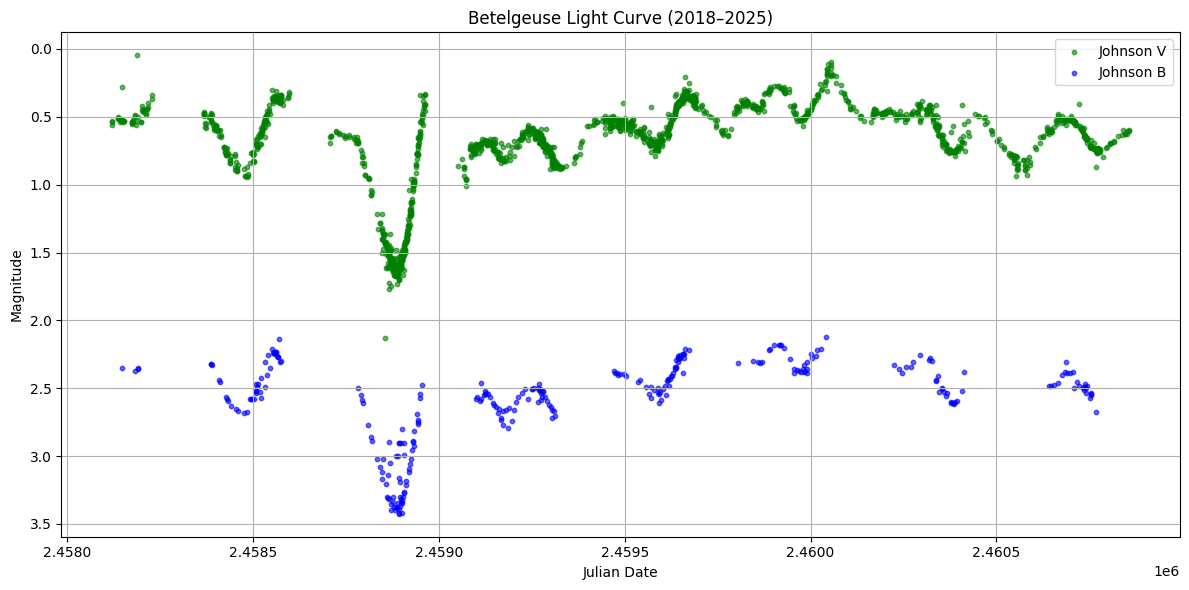

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Загружаем CSV с колонками
df = pd.read_csv("observations_20250813_063419.csv", header=0)

# Фильтруем по диапазону дат (JD)
# JD для 2018-01-01 ≈ 2458119, для 2025-12-31 ≈ 2463009
df = df[(df['jd'] >= 2458119) & (df['jd'] <= 2463009)]

# Разделяем по полосам
v_data = df[df['band'] == 'Johnson V']
b_data = df[df['band'] == 'Johnson B']

# Строим график
plt.figure(figsize=(12,6))
plt.scatter(v_data['jd'], v_data['mag'], s=10, color='green', alpha=0.6, label='Johnson V')
plt.scatter(b_data['jd'], b_data['mag'], s=10, color='blue', alpha=0.6, label='Johnson B')

# Настройка осей (в астрономии ось Y инвертируют — звёзды ярче внизу)
plt.gca().invert_yaxis()
plt.xlabel("Julian Date")
plt.ylabel("Magnitude")
plt.title("Betelgeuse Light Curve (2018–2025)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

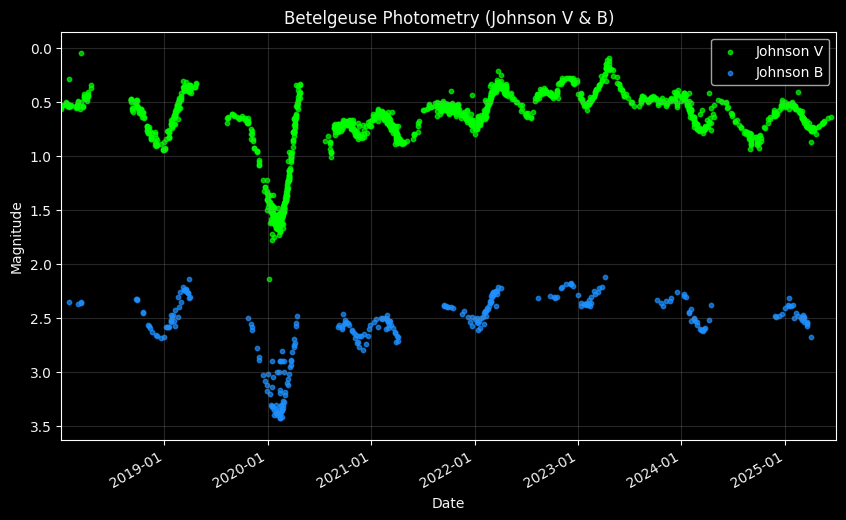

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.animation import FuncAnimation
from astropy.time import Time

# === Параметры ===
STEP = 10        # сколько точек добавляем за кадр
INTERVAL = 50    # мс между кадрами

# === Загрузка данных ===
df = pd.read_csv("observations_20250813_063419.csv")

# Преобразуем JD → обычные даты
df["date"] = Time(df["jd"], format="jd").to_datetime()

# Оставляем только V и B
df = df[df["band"].isin(["Johnson V", "Johnson B"])]

# Сортируем по времени
df.sort_values("date", inplace=True)

# Преобразуем даты в формат matplotlib
df["date_num"] = mdates.date2num(df["date"])

# Разделяем по фильтрам
v_data = df[df["band"] == "Johnson V"].copy()
b_data = df[df["band"] == "Johnson B"].copy()

# === График ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(10, 6))
ax.invert_yaxis()
ax.set_xlabel("Date", color="whitesmoke")
ax.set_ylabel("Magnitude", color="whitesmoke")
ax.set_title("Betelgeuse Photometry (Johnson V & B)", color="whitesmoke")
ax.tick_params(colors="whitesmoke")
ax.grid(True, color="gray", alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

v_scatter = ax.scatter([], [], color="lime", s=10, alpha=0.7, label="Johnson V")
b_scatter = ax.scatter([], [], color="dodgerblue", s=10, alpha=0.7, label="Johnson B")
ax.legend()

ax.set_xlim(df["date"].min(), df["date"].max())
ax.set_ylim(df["mag"].max() + 0.2, df["mag"].min() - 0.2)

# === init ===
def init():
    v_scatter.set_offsets(np.empty((0, 2)))
    b_scatter.set_offsets(np.empty((0, 2)))
    return v_scatter, b_scatter

# === update ===
def update(frame):
    end_idx = frame * STEP
    current_date = df["date"].iloc[min(end_idx, len(df)-1)]

    v_sub = v_data[v_data["date"] <= current_date]
    b_sub = b_data[b_data["date"] <= current_date]

    v_scatter.set_offsets(np.c_[v_sub["date_num"], v_sub["mag"]])
    b_scatter.set_offsets(np.c_[b_sub["date_num"], b_sub["mag"]])
    return v_scatter, b_scatter

# === Анимация ===
frames = int(np.ceil(len(df) / STEP))
anim = FuncAnimation(fig, update, init_func=init, frames=frames,
                     interval=INTERVAL, blit=True)

anim.save("betelgeuse_photometry.mp4", writer="ffmpeg", fps=30)
plt.show()

✅ Saved: betelgeuse_VB_2018_2025_sg_only.mp4


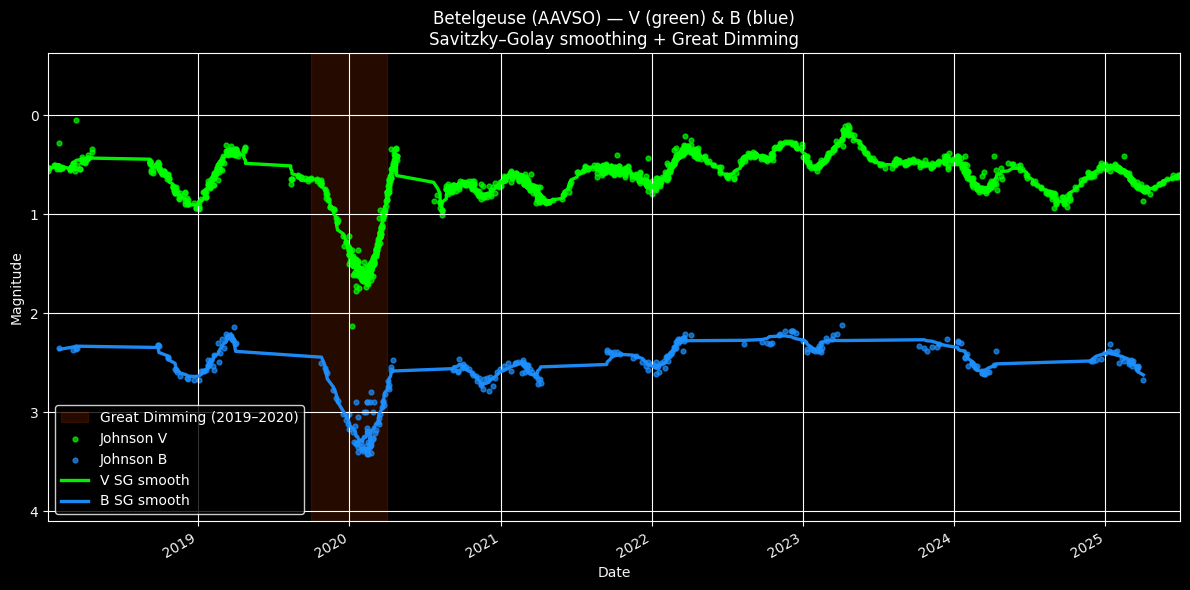

In [25]:
# Betelgeuse (AAVSO) — Johnson V (green) & B (blue)
# Анимация с Savitzky–Golay сглаженными кривыми и выделением Great Dimming

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.animation import FuncAnimation
from astropy.time import Time
from scipy.signal import savgol_filter  # pip install scipy

# ===== ПАРАМЕТРЫ =====
CSV_FILE   = "observations_20250813_063419.csv"
START_DATE = pd.to_datetime("2018-01-01")
END_DATE   = pd.to_datetime("2025-12-31")
STEP       = 10          # сколько новых точек (по общей шкале времени) добавляем за кадр
INTERVAL   = 50          # мс между кадрами
FPS_SAVE   = 30
SG_WIN     = 21          # окно Savitzky–Golay (нечётное)
SG_ORDER   = 3           # степень полинома
DIM_START  = pd.to_datetime("2019-10-01")
DIM_END    = pd.to_datetime("2020-03-31")
OUT_MP4    = "betelgeuse_VB_2018_2025_sg_only.mp4"
# =====================

# --- загрузка и подготовка ---
df = pd.read_csv(CSV_FILE)
df["band"] = df["band"].astype(str).str.strip()

# JD -> datetime и срез
df["date"] = Time(df["jd"], format="jd").to_datetime()
df = df[(df["date"] >= START_DATE) & (df["date"] <= END_DATE)]
df = df[df["band"].isin(["Johnson V", "Johnson B"])].copy()

df.sort_values("date", inplace=True)
df["date_num"] = mdates.date2num(df["date"])

# разбиение по фильтрам
v = df[df["band"] == "Johnson V"].copy()
b = df[df["band"] == "Johnson B"].copy()

# сглажённые кривые (S-G) на равномерной временной сетке каждой полосы
def sg_curve(d, win=SG_WIN, order=SG_ORDER):
    if d.empty or len(d) < win:
        return pd.DataFrame(columns=["date","mag","date_num"])
    d_sorted = d.sort_values("date").reset_index(drop=True)
    y = d_sorted["mag"].to_numpy()
    y_sg = savgol_filter(y, window_length=win, polyorder=order, mode="interp")
    out = d_sorted.copy()
    out["mag"] = y_sg
    return out

v_sg = sg_curve(v, SG_WIN, SG_ORDER)
b_sg = sg_curve(b, SG_WIN, SG_ORDER)

# --- графика ---
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

ax.set_title("Betelgeuse (AAVSO) — V (green) & B (blue)\nSavitzky–Golay smoothing + Great Dimming", color="white")
ax.set_xlabel("Date", color="whitesmoke")
ax.set_ylabel("Magnitude", color="whitesmoke")
ax.tick_params(colors="whitesmoke")
ax.grid(True, color=(1,1,1,0.25))
ax.invert_yaxis()

xmin_dt, xmax_dt = df["date"].min(), df["date"].max()
xmin, xmax = mdates.date2num(xmin_dt), mdates.date2num(xmax_dt)
ax.set_xlim(xmin, xmax)
y = df["mag"].to_numpy()
ymin, ymax = np.nanmin(y), np.nanmax(y)
pad = 0.2 * (ymax - ymin if ymax > ymin else 1.0)
ax.set_ylim(ymax + pad, ymin - pad)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

ax.axvspan(mdates.date2num(DIM_START), mdates.date2num(DIM_END),
           color="orangered", alpha=0.15, label="Great Dimming (2019–2020)")

# пустые артисты
v_scatter = ax.scatter([], [], s=12, alpha=0.7, color="lime",       label="Johnson V")
b_scatter = ax.scatter([], [], s=12, alpha=0.7, color="dodgerblue", label="Johnson B")
(v_sg_line,) = ax.plot([], [], color="lime",       lw=2.4, alpha=0.95, label="V SG smooth")
(b_sg_line,) = ax.plot([], [], color="dodgerblue", lw=2.4, alpha=0.95, label="B SG smooth")

ax.legend(loc="best", facecolor=(0,0,0,0.3), edgecolor=(1,1,1,0.3), labelcolor="white")

# --- init ---
def init():
    v_scatter.set_offsets(np.empty((0, 2)))
    b_scatter.set_offsets(np.empty((0, 2)))
    v_sg_line.set_data([], [])
    b_sg_line.set_data([], [])
    return v_scatter, b_scatter, v_sg_line, b_sg_line

# --- анимация (синхронно по дате) ---
frames = int(np.ceil(len(df) / STEP))

def update(frame):
    end_idx = min((frame + 1) * STEP, len(df))
    current_num = df["date_num"].iloc[end_idx - 1]

    # точки до текущей даты
    v_sub = v[v["date_num"] <= current_num]
    b_sub = b[b["date_num"] <= current_num]
    v_scatter.set_offsets(np.c_[v_sub["date_num"].to_numpy(), v_sub["mag"].to_numpy()])
    b_scatter.set_offsets(np.c_[b_sub["date_num"].to_numpy(), b_sub["mag"].to_numpy()])

    # S-G сглаженные кривые до текущей даты
    if not v_sg.empty:
        vsg = v_sg[v_sg["date_num"] <= current_num]
        v_sg_line.set_data(vsg["date_num"].to_numpy(), vsg["mag"].to_numpy())
    if not b_sg.empty:
        bsg = b_sg[b_sg["date_num"] <= current_num]
        b_sg_line.set_data(bsg["date_num"].to_numpy(), bsg["mag"].to_numpy())

    return v_scatter, b_scatter, v_sg_line, b_sg_line

anim = FuncAnimation(fig, update, init_func=init, frames=frames, interval=INTERVAL, blit=False, repeat=False)

# сохранить mp4 (перезапишем, если есть)
if os.path.exists(OUT_MP4):
    os.remove(OUT_MP4)
anim.save(OUT_MP4, writer="ffmpeg", fps=FPS_SAVE, dpi=150)
print(f"✅ Saved: {OUT_MP4}")

plt.tight_layout()
plt.show()